# Project - Ethics of AI
## | Make Ethical a Classic AI Workflow |

---

## Downloading

In [261]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import random

---

## Data Ingestion

### Import

#### In this part we are loading job applicant dataset and setting random seed for reproducibility

In [262]:
df_init = pd.read_csv("../data/job_applicant_dataset.csv")
random.seed(7)

## Exploration

#### **10,000 applicants** with 9 feature : 
- **Target variable:** `Best Match` (0 = Not Matched, 1 = Matched)
- **Protected attributes:** Gender, Race, Ethnicity, Age
- **Other features:** Job Role, Resume, Job Description

In [263]:
display(df_init)
print("Dataset shape:", df_init.shape)

#

,Job Applicant Name,Age,Gender,Race,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,"Proficient in Injury Prevention, Motivation, N...",Fitness Coach,A Fitness Coach is responsible for helping cl...,0
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,"Proficient in Healthcare, Pharmacology, Medica...",Physician,"Diagnose and treat illnesses, prescribe medica...",0
2,Sarah Martin,46,Female,White/Caucasian,Dutch,"Proficient in Forecasting, Financial Modelling...",Financial Analyst,"As a Financial Analyst, you will be responsibl...",0
3,Keith Hughes,43,Male,Negroid/Black,Caribbean,"Proficient in Budgeting, Supply Chain Optimiza...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1
4,James Davis,49,Male,White/Caucasian,English,"Proficient in Logistics, Negotiation, Procurem...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1
...,...,...,...,...,...,...,...,...,...
9995,Jada Williams,30,Female,Negroid/Black,Ghanaian,"Proficient in Biology, Regulatory Compliance, ...",Biomedical Engineer,A Biomedical Engineer designs and develops med...,0
9996,Jaden Carter,52,Male,Negroid/Black,Nigerian,"Proficient in Communication, Teamwork, Lesson ...",Teacher,A Teacher shapes the future of students by del...,0
9997,Mia Foster,25,Female,White/Caucasian,German,"Proficient in Medical Terminology, Critical Th...",Physician,"Diagnose and treat illnesses, prescribe medica...",0
9998,Stella Green,51,Female,White/Caucasian,Irish,"Proficient in Exercise Programming, Motivation...",Fitness Coach,A Fitness Coach is responsible for helping cl...,1


Dataset shape: (10000, 9)


#### Data Quality Check
 - No missing values detected
 - All 10,000 entries are complete
 - Data types are appropriate (int64 for numerical, object for categorical)

In [264]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Applicant Name  10000 non-null  object
 1   Age                 10000 non-null  int64 
 2   Gender              10000 non-null  object
 3   Race                10000 non-null  object
 4   Ethnicity           10000 non-null  object
 5   Resume              10000 non-null  object
 6   Job Roles           10000 non-null  object
 7   Job Description     10000 non-null  object
 8   Best Match          10000 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 703.2+ KB


In [265]:
df_init.describe()

,Age,Best Match
count,10000.000000,10000.0000
mean,40.045200,0.4850
std,8.950909,0.4998
min,25.000000,0.0000
25%,32.000000,0.0000
50%,40.000000,0.0000
75%,48.000000,1.0000
max,55.000000,1.0000


In [266]:
print("Missing values per column:")
print(df_init.isnull().sum())

Missing values per column:
Job Applicant Name    0
Age                   0
Gender                0
Race                  0
Ethnicity             0
Resume                0
Job Roles             0
Job Description       0
Best Match            0
dtype: int64


### Feature Cardinality
- **2 genders:** Male, Female
- **3 racial groups:** Mongoloid/Asian, White/Caucasian, Negroid/Black
- **21 ethnicities:** Vietnamese, Filipino, Dutch, Caribbean, etc.
- **51 job roles:** Wide variety of professions

In [267]:
print("Unique Genders:", df_init['Gender'].unique())
print("Number of unique genders:", df_init['Gender'].nunique())
print("\nUnique Races:", df_init['Race'].unique())
print("Number of unique races:", df_init['Race'].nunique())
print("\nUnique Ethnicities:", df_init['Ethnicity'].unique())
print("Number of unique ethnicities:", df_init['Ethnicity'].nunique())
print("\nUnique Job Roles:", df_init['Job Roles'].unique())
print("Number of unique job roles:", df_init['Job Roles'].nunique())

Unique Genders: ['Male' 'Female']
Number of unique genders: 2

Unique Races: ['Mongoloid/Asian' 'White/Caucasian' 'Negroid/Black']
Number of unique races: 3

Unique Ethnicities: ['Vietnamese' 'Filipino' 'Dutch' 'Caribbean' 'English' 'African' 'Thai'
 'French' 'Indian' 'Ethiopian' 'Korean' 'Irish' 'Kenyan' 'Italian'
 'Polish' 'Jamaican' 'Chinese' 'German' 'Nigerian' 'Japanese' 'Ghanaian']
Number of unique ethnicities: 21

Unique Job Roles: ['Fitness Coach' 'Physician' 'Financial Analyst' 'Supply Chain Manager'
 'Database Administrator' 'Architect' 'Operations Manager'
 'Cybersecurity Analyst' 'Software Engineer' 'Urban Planner'
 'Machine Learning Engineer' 'Personal Trainer' 'Biomedical Engineer'
 'Nurse' 'Systems Analyst' 'Product Manager' 'Content Writer' 'Pharmacist'
 'Chef' 'AI Researcher' 'Data Analyst' 'Psychologist' 'Civil Engineer'
 'Accountant' 'Graphic Designer' 'Web Developer' 'Cloud Architect'
 'AI Specialist' 'Dentist' 'Pilot' 'UX Designer' 'Teacher' 'HR Specialist'
 'Veter

### Target Variable Balance
- **48.5% matched** (4,850 applicants)
- **51.5% not matched** (5,150 applicants)
- Dataset is relatively balanced (no severe class imbalance

In [268]:
print("Best Match distribution:")
print(df_init['Best Match'].value_counts())
print("\nBest Match proportions:")
print(df_init['Best Match'].value_counts(normalize=True))

Best Match distribution:
Best Match
0    5150
1    4850
Name: count, dtype: int64

Best Match proportions:
Best Match
0    0.515
1    0.485
Name: proportion, dtype: float64


## 3. Bias Detection and Analysis



#### We analyze match rates across different demographic groups to identify systematic biases

**Methodology:** Calculate match rate (% of applicants matched) for each group and compare to overall average (48.5%).

**Bias indicator:** Groups with match rates significantly above/below 48.5% indicate potential discrimination.

#### Gender Bias Analysis
**Question:** Are males and females matched at equal rates?

In [269]:
def plot_gender_bias(gender_data: pd.DataFrame, overall_avg: float) -> None:

    colors = ['#2ecc71' if x > overall_avg else '#e74c3c' for x in gender_data['Match_Rate']]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(gender_data)), gender_data['Match_Rate'], 
                  color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=overall_avg, color='#3498db', linestyle='--', linewidth=2, 
               label=f'Overall Avg: {overall_avg:.2%}')
    ax.set_xticks(range(len(gender_data)))
    ax.set_xticklabels(gender_data.index, rotation=0, fontsize=12)
    ax.set_ylabel('Match Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
    ax.set_title('Best Match Rate by Gender', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    for i, (idx, row) in enumerate(gender_data.iterrows()):
        ax.text(i, row['Match_Rate'] + 0.01, 
                f"{row['Match_Rate']:.1%}\n(n={int(row['Total_Applicants'])})", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

 ## **Gender Bias**

 - Male match rate: 61.3%
 - Female match rate: 35.4%
 - **Gap: 25.9 percentage points** (73% higher for males)

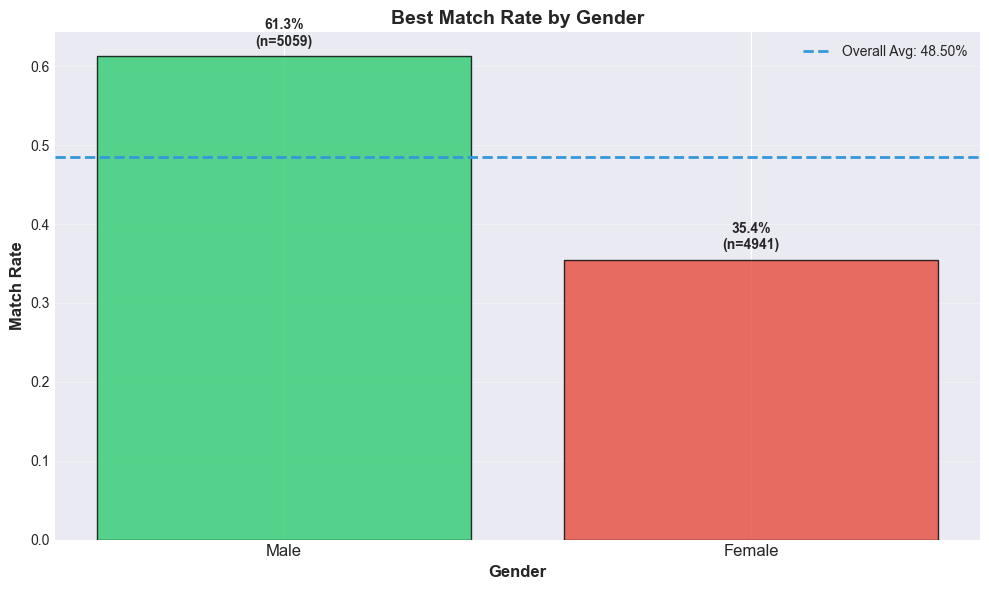

In [270]:
overall_avg = df_init['Best Match'].mean()
plot_gender_bias(gender_match, overall_avg)

## Race Bias Analysis
**Question:** Do different racial groups face discrimination?

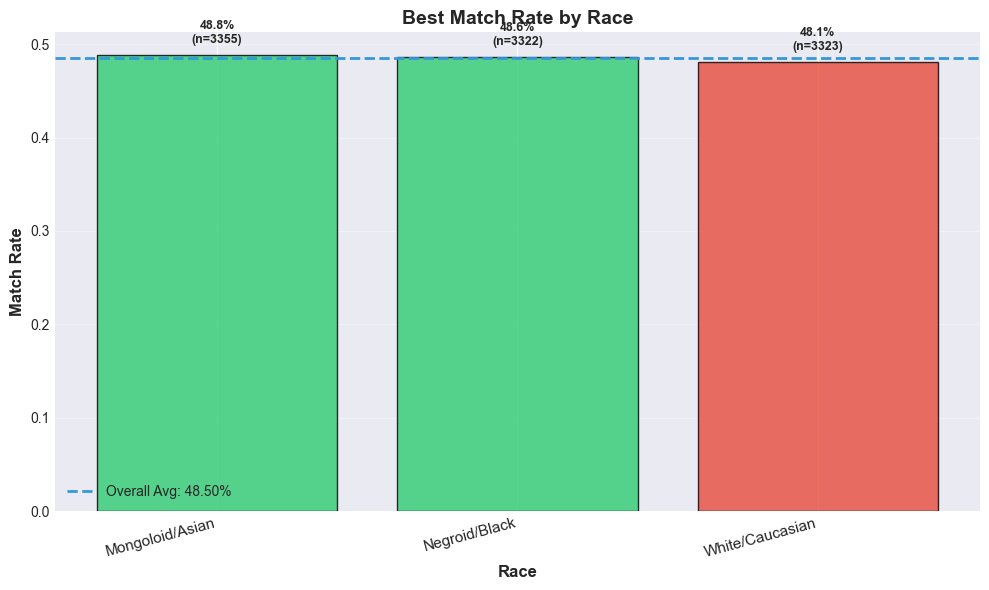

In [271]:
def plot_race_bias(race_data: pd.DataFrame, overall_avg: float) -> None:
    """Plot race bias bar chart."""
    colors = ['#2ecc71' if x > overall_avg else '#e74c3c' for x in race_data['Match_Rate']]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(race_data)), race_data['Match_Rate'], 
                  color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=overall_avg, color='#3498db', linestyle='--', linewidth=2, 
               label=f'Overall Avg: {overall_avg:.2%}')
    ax.set_xticks(range(len(race_data)))
    ax.set_xticklabels(race_data.index, rotation=15, fontsize=11, ha='right')
    ax.set_ylabel('Match Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Race', fontsize=12, fontweight='bold')
    ax.set_title('Best Match Rate by Race', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    for i, (idx, row) in enumerate(race_data.iterrows()):
        ax.text(i, row['Match_Rate'] + 0.01, 
                f"{row['Match_Rate']:.1%}\n(n={int(row['Total_Applicants'])})", 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_race_bias(race_match, overall_avg)

## Ethnicity Bias Analysis (Top 10)
**Question:** Which ethnicities have the highest match rates?

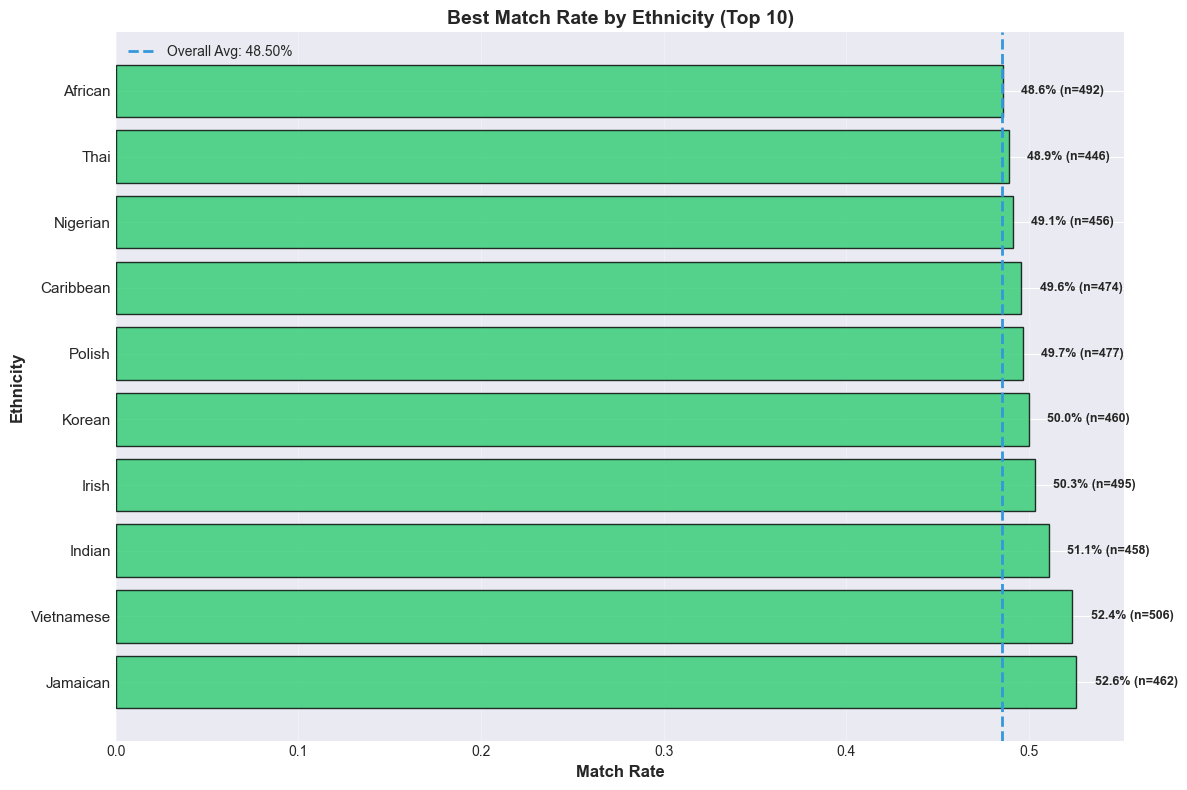

In [272]:
def plot_ethnicity_top10(ethnicity_data: pd.DataFrame, overall_avg: float) -> None:
    """Plot top 10 ethnicities by match rate."""
    ethnicity_top10 = ethnicity_data.head(10)
    colors = ['#2ecc71' if x > overall_avg else '#e74c3c' for x in ethnicity_top10['Match_Rate']]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(range(len(ethnicity_top10)), ethnicity_top10['Match_Rate'], 
                   color=colors, alpha=0.8, edgecolor='black')
    ax.axvline(x=overall_avg, color='#3498db', linestyle='--', linewidth=2, 
               label=f'Overall Avg: {overall_avg:.2%}')
    ax.set_yticks(range(len(ethnicity_top10)))
    ax.set_yticklabels(ethnicity_top10.index, fontsize=11)
    ax.set_xlabel('Match Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Ethnicity', fontsize=12, fontweight='bold')
    ax.set_title('Best Match Rate by Ethnicity (Top 10)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    
    for i, (idx, row) in enumerate(ethnicity_top10.iterrows()):
        ax.text(row['Match_Rate'] + 0.01, i, 
                f"{row['Match_Rate']:.1%} (n={int(row['Total_Applicants'])})", 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_ethnicity_top10(ethnicity_match, overall_avg)

## Ethnicity Bias Analysis (Bottom 10)
**Question:** Which ethnicities have the lowest match rates?

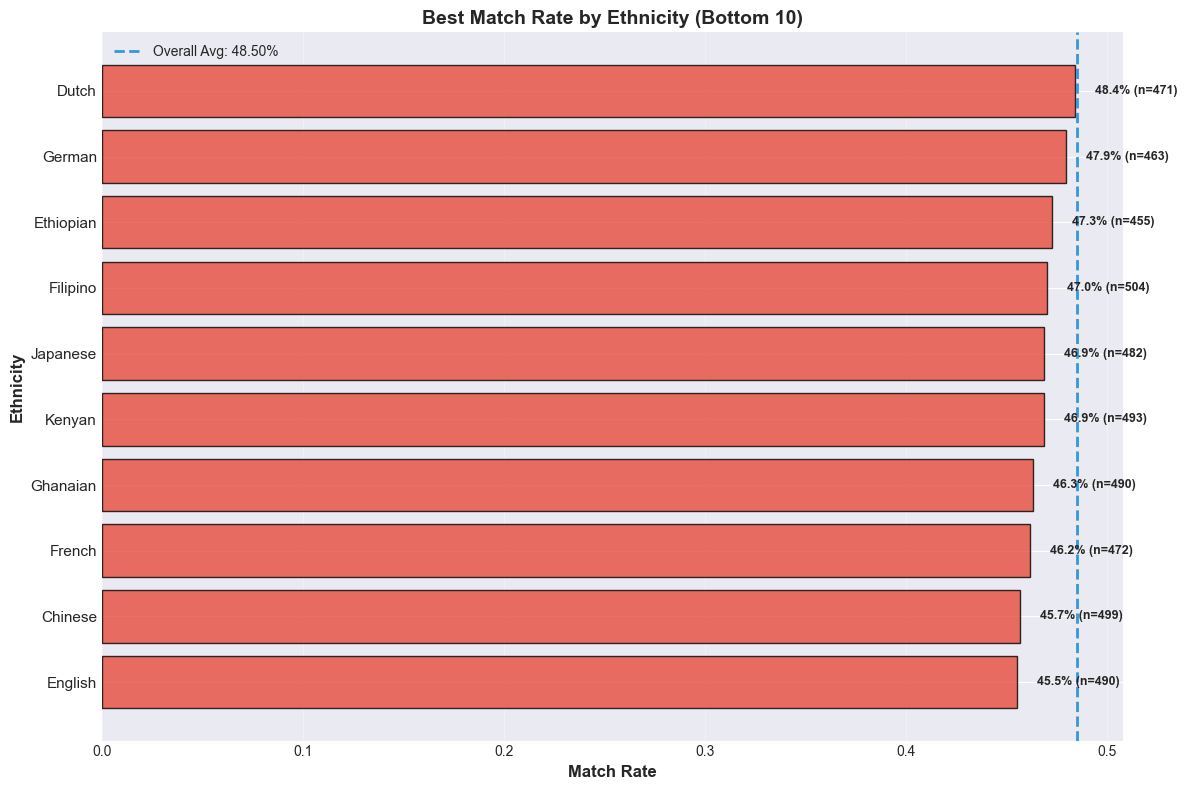

In [273]:
def plot_ethnicity_bottom10(ethnicity_data: pd.DataFrame, overall_avg: float) -> None:
    """Plot bottom 10 ethnicities by match rate."""
    ethnicity_bottom10 = ethnicity_data.sort_values('Match_Rate', ascending=True).head(10)
    colors = ['#2ecc71' if x > overall_avg else '#e74c3c' for x in ethnicity_bottom10['Match_Rate']]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(range(len(ethnicity_bottom10)), ethnicity_bottom10['Match_Rate'], 
                   color=colors, alpha=0.8, edgecolor='black')
    ax.axvline(x=overall_avg, color='#3498db', linestyle='--', linewidth=2, 
               label=f'Overall Avg: {overall_avg:.2%}')
    ax.set_yticks(range(len(ethnicity_bottom10)))
    ax.set_yticklabels(ethnicity_bottom10.index, fontsize=11)
    ax.set_xlabel('Match Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Ethnicity', fontsize=12, fontweight='bold')
    ax.set_title('Best Match Rate by Ethnicity (Bottom 10)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    
    for i, (idx, row) in enumerate(ethnicity_bottom10.iterrows()):
        ax.text(row['Match_Rate'] + 0.01, i, 
                f"{row['Match_Rate']:.1%} (n={int(row['Total_Applicants'])})", 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_ethnicity_bottom10(ethnicity_match, overall_avg)

#### Age Bias Analysis
**Question:** Does age affect matching decisions?

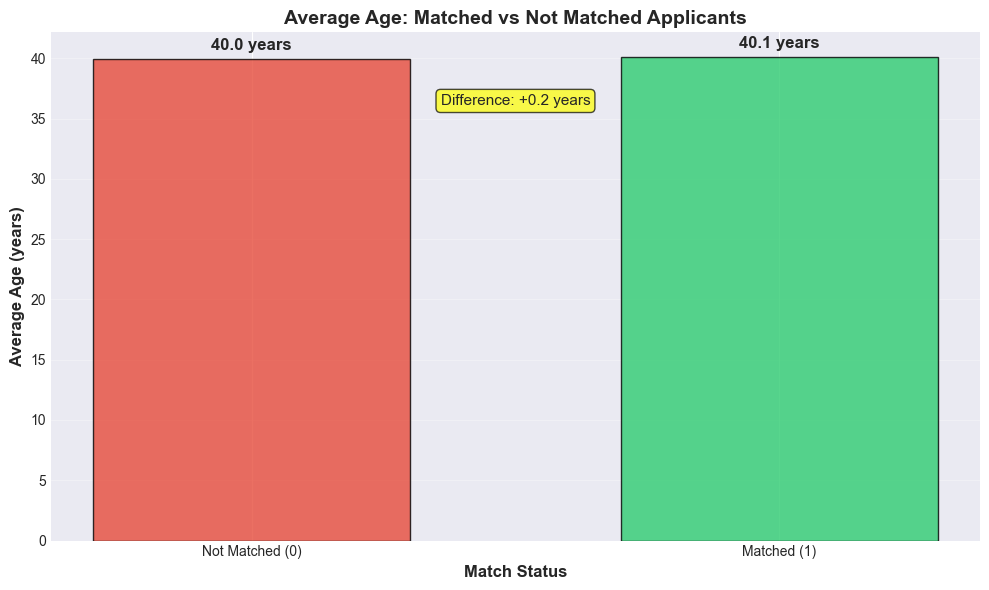

In [274]:
def plot_age_comparison_bar(df: pd.DataFrame, target_col: str = 'Best Match') -> None:
    """Plot mean age comparison between matched and not matched applicants."""
    age_by_match = df.groupby(target_col)['Age'].mean()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#e74c3c', '#2ecc71']
    bars = ax.bar(['Not Matched (0)', 'Matched (1)'], age_by_match.values, 
                  color=colors, alpha=0.8, edgecolor='black', width=0.6)
    
    for i, (value, bar) in enumerate(zip(age_by_match.values, bars)):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.5, 
                f'{value:.1f} years', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Average Age (years)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Match Status', fontsize=12, fontweight='bold')
    ax.set_title('Average Age: Matched vs Not Matched Applicants', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    diff = age_by_match.values[1] - age_by_match.values[0]
    ax.text(0.5, max(age_by_match.values) * 0.9, 
            f'Difference: {diff:+.1f} years', 
            ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

plot_age_comparison_bar(df_init)

## Age Distribution Comparison
**Question:** How are ages distributed between matched and not matched groups?

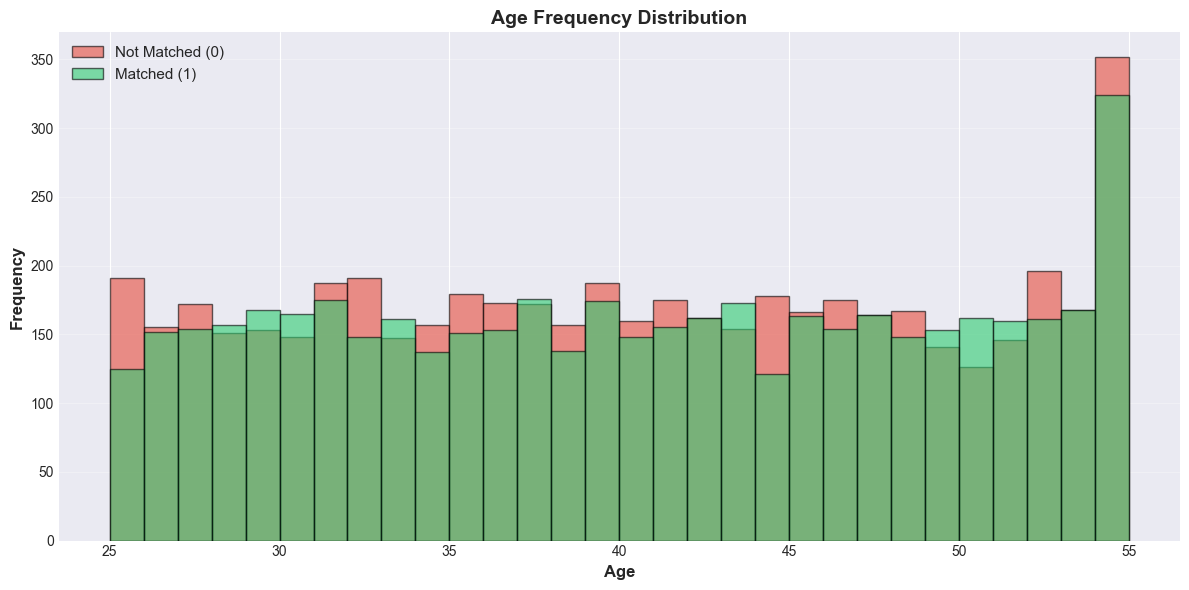

In [275]:
def plot_age_histogram(df: pd.DataFrame, target_col: str = 'Best Match') -> None:
    """Plot age frequency histogram by match status."""
    ages_matched = df[df[target_col]==1]['Age']
    ages_not_matched = df[df[target_col]==0]['Age']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(ages_not_matched, bins=30, alpha=0.6, label='Not Matched (0)', 
            color='#e74c3c', edgecolor='black')
    ax.hist(ages_matched, bins=30, alpha=0.6, label='Matched (1)', 
            color='#2ecc71', edgecolor='black')
    ax.set_xlabel('Age', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title('Age Frequency Distribution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_age_histogram(df_init)

## Intersectional Analysis: Gender × Race
**Question:** Does the combination of gender and race create compounded bias?

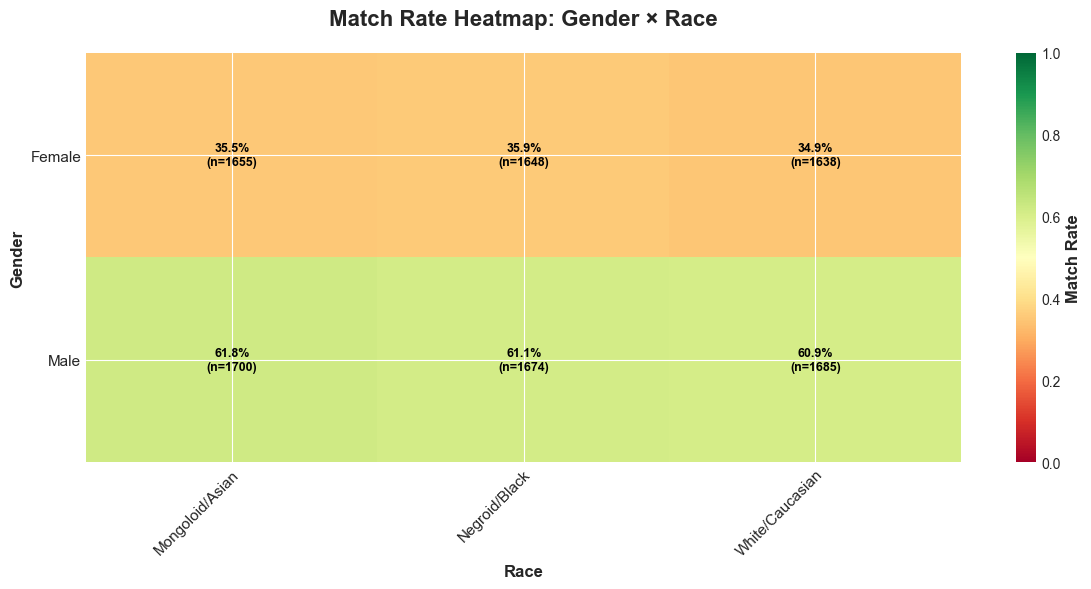

mean  count
Gender Race                            
Male   Mongoloid/Asian  0.618235   1700
       Negroid/Black    0.610514   1674
       White/Caucasian  0.608902   1685
Female Negroid/Black    0.359223   1648
       Mongoloid/Asian  0.354683   1655
       White/Caucasian  0.349206   1638

In [276]:
def plot_gender_race_heatmap(df: pd.DataFrame, target_col: str = 'Best Match') -> pd.DataFrame:
    """Plot heatmap for Gender × Race cross-analysis."""
    cross_analysis = df.groupby(['Gender', 'Race'])[target_col].agg(['mean', 'count'])
    cross_pivot = cross_analysis['mean'].unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(cross_pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(len(cross_pivot.columns)))
    ax.set_yticks(np.arange(len(cross_pivot.index)))
    ax.set_xticklabels(cross_pivot.columns, fontsize=11)
    ax.set_yticklabels(cross_pivot.index, fontsize=11)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Match Rate', fontsize=12, fontweight='bold')
    
    for i in range(len(cross_pivot.index)):
        for j in range(len(cross_pivot.columns)):
            if (cross_pivot.index[i], cross_pivot.columns[j]) in cross_analysis.index:
                count = cross_analysis.loc[(cross_pivot.index[i], cross_pivot.columns[j]), 'count']
                ax.text(j, i, f"{cross_pivot.values[i, j]:.1%}\n(n={int(count)})",
                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    ax.set_title('Match Rate Heatmap: Gender × Race', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Race', fontsize=12, fontweight='bold')
    ax.set_ylabel('Gender', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return cross_analysis.sort_values('mean', ascending=False)

cross_stats = plot_gender_race_heatmap(df_init)
display(cross_stats)

**Question:** Are certain professions systematically disadvantaged?

In [277]:
def analyze_job_role_bias(df: pd.DataFrame) -> pd.DataFrame:

    print("="*50)
    print("BIAS ANALYSIS: JOB ROLES")
    print("="*50)
    job_stats = calculate_match_rate_by_feature(df, 'Job Roles')
    return job_stats

job_role_match = analyze_job_role_bias(df_init)
display(job_role_match.head(15))
display(job_role_match.tail(15))

BIAS ANALYSIS: JOB ROLES


,Match_Rate,Total_Matches,Total_Applicants
Job Roles,,,
Supply Chain Manager,0.582915,116,199
Financial Analyst,0.582524,120,206
Psychologist,0.554974,106,191
Chef,0.549505,111,202
Customer Service Representative,0.548387,102,186
Urban Planner,0.545455,120,220
Software Engineer,0.543147,107,197
Content Writer,0.540698,93,172
Pilot,0.540670,113,209


,Match_Rate,Total_Matches,Total_Applicants
Job Roles,,,
Fitness Coach,0.474490,93,196
Marketing Manager,0.473958,91,192
Systems Analyst,0.472906,96,203
Veterinarian,0.469072,91,194
Nurse,0.467836,80,171
Event Planner,0.457711,92,201
Electrician,0.456853,90,197
Personal Trainer,0.451327,102,226
Social Worker,0.446701,88,197


**Question:** Are longer or shorter resumes penalized?

In [278]:
def analyze_resume_length_bias(df: pd.DataFrame) -> pd.DataFrame:
    """Analyze if resume length (skills count) affects match rates."""
    print("="*50)
    print("BIAS ANALYSIS: RESUME LENGTH")
    print("="*50)
    
    # Count skills mentioned in resume
    df['Resume_Length'] = df['Resume'].str.len()
    df['Resume_Length_Group'] = pd.cut(df['Resume_Length'], bins=5, labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
    
    resume_stats = df.groupby('Resume_Length_Group')['Best Match'].agg(['mean', 'count'])
    resume_stats.columns = ['Match_Rate', 'Count']
    
    display(resume_stats)
    return resume_stats

resume_stats = analyze_resume_length_bias(df_init)

BIAS ANALYSIS: RESUME LENGTH


/var/folders/c5/6ygj2sy13k95cbxn8tn_8l1h0000gn/T/ipykernel_5016/2492318604.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resume_stats = df.groupby('Resume_Length_Group')['Best Match'].agg(['mean', 'count'])


,Match_Rate,Count
Resume_Length_Group,,
Very Short,0.447059,170
Short,0.498504,3009
Medium,0.480786,5699
Long,0.478505,1070
Very Long,0.423077,52


**Question:** Which ethnic-gender combinations face the most discrimination?

In [279]:
def analyze_ethnicity_gender_interaction(df: pd.DataFrame) -> pd.DataFrame:
    """Analyze if ethnicity+gender combinations show bias."""
    print("="*50)
    print("INTERSECTIONAL BIAS: ETHNICITY × GENDER")
    print("="*50)
    
    eth_gender_stats = df.groupby(['Ethnicity', 'Gender'])['Best Match'].agg(['mean', 'count'])
    eth_gender_stats.columns = ['Match_Rate', 'Count']
    
    # Show top 10 and bottom 10
    print("\nTOP 10 (Highest Match Rates):")
    display(eth_gender_stats.sort_values('Match_Rate', ascending=False).head(10))
    
    print("\nBOTTOM 10 (Lowest Match Rates):")
    display(eth_gender_stats.sort_values('Match_Rate', ascending=True).head(10))
    
    return eth_gender_stats

eth_gender_stats = analyze_ethnicity_gender_interaction(df_init)

INTERSECTIONAL BIAS: ETHNICITY × GENDER

TOP 10 (Highest Match Rates):


,,Match_Rate,Count
Ethnicity,Gender,,
Indian,Male,0.659664,238
Jamaican,Male,0.655172,232
African,Male,0.648855,262
Korean,Male,0.635556,225
Italian,Male,0.634043,235
Thai,Male,0.633333,210
Vietnamese,Male,0.628253,269
Polish,Male,0.627119,236
Ethiopian,Male,0.622807,228



BOTTOM 10 (Lowest Match Rates):


,,Match_Rate,Count
Ethnicity,Gender,,
African,Female,0.300000,230
Chinese,Female,0.306034,232
Ethiopian,Female,0.321586,227
Italian,Female,0.327273,220
French,Female,0.332016,253
Ghanaian,Female,0.334694,245
English,Female,0.340426,235
Japanese,Female,0.341365,249
German,Female,0.344828,232


**Question:** Are certain professions more gender-biased than others?

In [280]:
def analyze_job_gender_interaction(df: pd.DataFrame) -> pd.DataFrame:
    """Analyze if certain jobs are biased by gender (occupational segregation)."""
    print("="*50)
    print("INTERSECTIONAL BIAS: JOB ROLE × GENDER")
    print("="*50)
    
    job_gender_stats = df.groupby(['Job Roles', 'Gender'])['Best Match'].agg(['mean', 'count'])
    job_gender_stats.columns = ['Match_Rate', 'Count']
    
    # Calculate gender gap per job role
    job_gender_pivot = job_gender_stats['Match_Rate'].unstack(fill_value=0)
    if 'Male' in job_gender_pivot.columns and 'Female' in job_gender_pivot.columns:
        job_gender_pivot['Gender_Gap'] = job_gender_pivot['Male'] - job_gender_pivot['Female']
        job_gender_pivot['Abs_Gap'] = abs(job_gender_pivot['Gender_Gap'])
        
        print("\nJobs with LARGEST Gender Gap (Male advantage):")
        display(job_gender_pivot.sort_values('Gender_Gap', ascending=False).head(10))
        
        print("\nJobs with SMALLEST Gender Gap (Most Fair):")
        display(job_gender_pivot.sort_values('Abs_Gap', ascending=True).head(10))
    
    return job_gender_stats

job_gender_stats = analyze_job_gender_interaction(df_init)

INTERSECTIONAL BIAS: JOB ROLE × GENDER

Jobs with LARGEST Gender Gap (Male advantage):


Gender,Female,Male,Gender_Gap,Abs_Gap
Job Roles,,,,
Journalist,0.061856,0.956044,0.894188,0.894188
Financial Analyst,0.100000,0.956897,0.856897,0.856897
Electrician,0.066038,0.912088,0.846050,0.846050
Chef,0.068966,0.913043,0.844078,0.844078
Data Analyst,0.094737,0.934579,0.839843,0.839843
Lawyer,0.082353,0.920792,0.838439,0.838439
Mechanical Engineer,0.073394,0.904762,0.831367,0.831367
Accountant,0.087379,0.916667,0.829288,0.829288
Urban Planner,0.090909,0.917355,0.826446,0.826446



Jobs with SMALLEST Gender Gap (Most Fair):


Gender,Female,Male,Gender_Gap,Abs_Gap
Job Roles,,,,
Legal Consultant,0.077670,0.088889,0.011219,0.011219
AI Researcher,0.072165,0.057692,-0.014473,0.014473
UX Designer,0.817073,0.145631,-0.671442,0.671442
Teacher,0.863636,0.191011,-0.672625,0.672625
Creative Director,0.831683,0.127451,-0.704232,0.704232
Graphic Designer,0.879121,0.168539,-0.710582,0.710582
Physician,0.111111,0.828829,0.717718,0.717718
Biomedical Engineer,0.142857,0.891089,0.748232,0.748232
Web Developer,0.113402,0.863636,0.750234,0.750234


## Visual comparison of which jobs have the largest gender disparities.

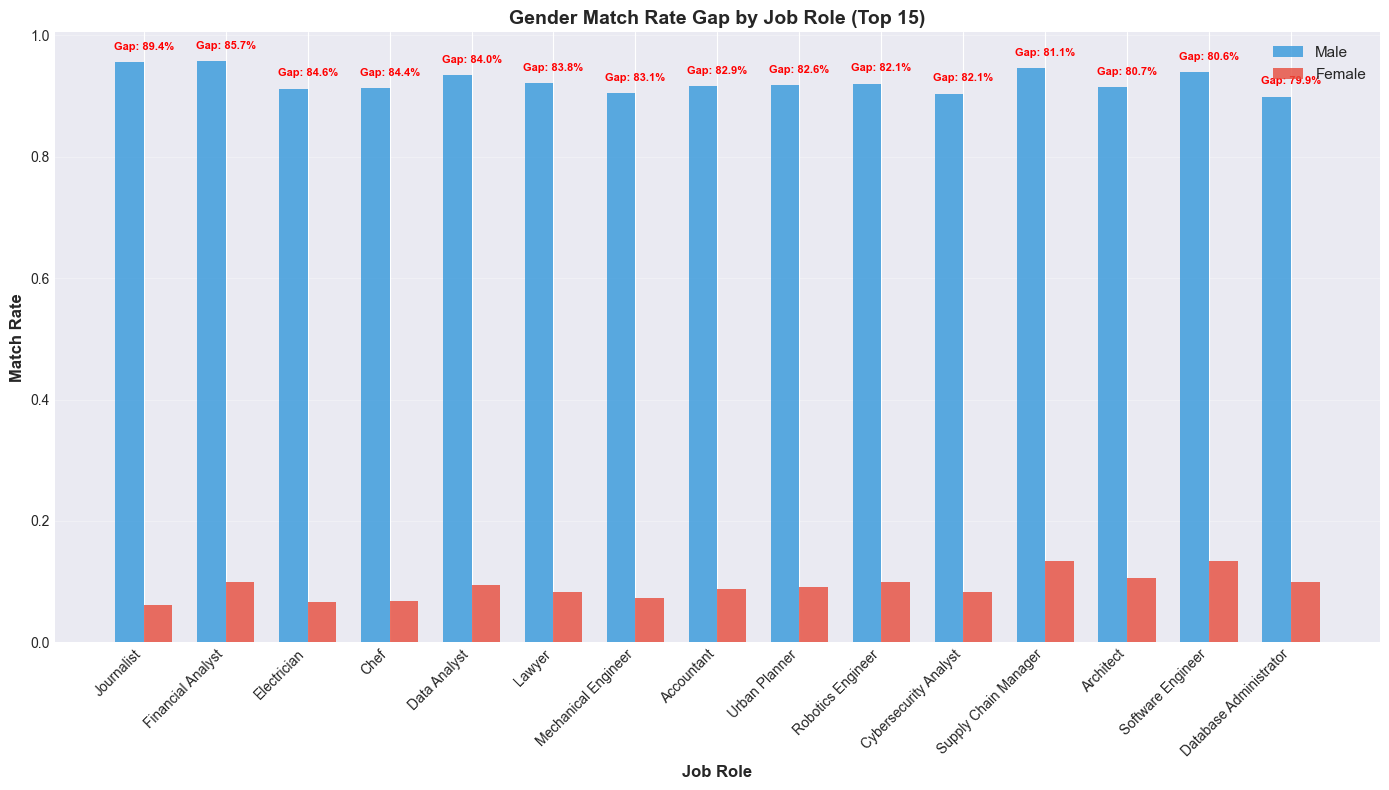

In [281]:
def plot_job_role_gender_gap(df: pd.DataFrame) -> None:
    """Visualize which job roles have the biggest gender bias."""
    job_gender_stats = df.groupby(['Job Roles', 'Gender'])['Best Match'].mean().unstack(fill_value=0)
    
    if 'Male' in job_gender_stats.columns and 'Female' in job_gender_stats.columns:
        job_gender_stats['Gap'] = job_gender_stats['Male'] - job_gender_stats['Female']
        top_gaps = job_gender_stats.nlargest(15, 'Gap')
        
        fig, ax = plt.subplots(figsize=(14, 8))
        x = np.arange(len(top_gaps))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, top_gaps['Male'], width, label='Male', color='#3498db', alpha=0.8)
        bars2 = ax.bar(x + width/2, top_gaps['Female'], width, label='Female', color='#e74c3c', alpha=0.8)
        
        ax.set_ylabel('Match Rate', fontsize=12, fontweight='bold')
        ax.set_xlabel('Job Role', fontsize=12, fontweight='bold')
        ax.set_title('Gender Match Rate Gap by Job Role (Top 15)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(top_gaps.index, rotation=45, ha='right', fontsize=10)
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        # Add gap annotations
        for i, (idx, row) in enumerate(top_gaps.iterrows()):
            ax.text(i, max(row['Male'], row['Female']) + 0.02, 
                   f"Gap: {row['Gap']:.1%}", 
                   ha='center', fontsize=8, fontweight='bold', color='red')
        
        plt.tight_layout()
        plt.show()

plot_job_role_gender_gap(df_init)

## Conclusion

### There is a severe Gender Bias : 

-  Male: 61.3% | Female: 35.4%
- **Gap: 25.9%** - Males are 73% more likely to be matched
- Consistent across all ages and races

### There is a Job Role Bias :

- AI Researcher: 6.5% vs Supply Chain Manager: 58.3%
- **Gap: 52%** between professions

### There is a Occupational Gender Segregation : 

- Journalist: 89% gap (favors males)
- Veterinarian: 75% gap (favors females)
- **Different jobs discriminate in different directions**


## Bias reducing

In [282]:
from sklearn.utils import resample


**Objective:** Reduce gender gap from 25.9% to under 5% while preserving dataset diversity.

- We implement a resampling approach to balance gender representation in matched applicants.
- Upsampling of underrepresented groups to achieve demographic parity across protected attributes.


In [283]:
def reduce_gender_bias(df: pd.DataFrame, target_col: str = 'Best Match') -> pd.DataFrame:

    # Separate dataset into four groups based on gender and match status
    male_matched = df[(df['Gender'] == 'Male') & (df[target_col] == 1)]
    male_not_matched = df[(df['Gender'] == 'Male') & (df[target_col] == 0)]
    female_matched = df[(df['Gender'] == 'Female') & (df[target_col] == 1)]
    female_not_matched = df[(df['Gender'] == 'Female') & (df[target_col] == 0)]
    
    print("Original distribution:")
    print(f"Male matched: {len(male_matched)}")
    print(f"Male not matched: {len(male_not_matched)}")
    print(f"Female matched: {len(female_matched)}")
    print(f"Female not matched: {len(female_not_matched)}")
    
    # Upsample female matched group to achieve gender parity
    target_size = len(male_matched)
    female_matched_upsampled = resample(
        female_matched,
        n_samples=target_size,
        replace=True,
        random_state=42
    )
    
    # Reconstruct dataset
    df_debiased = pd.concat([
        male_matched,
        male_not_matched,
        female_matched_upsampled,
        female_not_matched
    ])
    
    # Shuffle to avoid ordering bias
    df_debiased = df_debiased.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\nDebiased dataset created:")
    print(f"Original size: {len(df)}")
    print(f"New size: {len(df_debiased)}")
    
    return df_debiased

# Apply bias mitigation
df_debiased = reduce_gender_bias(df_init)

Original distribution:
Male matched: 3099
Male not matched: 1960
Female matched: 1751
Female not matched: 3190

Debiased dataset created:
Original size: 10000
New size: 11348
